# Part 1 - SOM


In [3]:
!pip install minisom

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset

dataset = pd.read_csv('Credit_Card_Applications.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Feature Scaling

from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
X = sc.fit_transform(X)

# Training the SOM
from minisom import MiniSom
# sigma: radius of different neighbors from the grid
# learning_rate: hyperparameter with which weights are updated each iteration
# x, y dimension of som. Not too small (miss outliners) and not too large(needs huge data to get accurate outliners).
som = MiniSom(x = 10, y = 10, input_len=15, sigma=1.0, learning_rate=0.5)
som.random_weights_init(X)
som.train_random(data=X, num_iteration=100)

# Visualizing the results

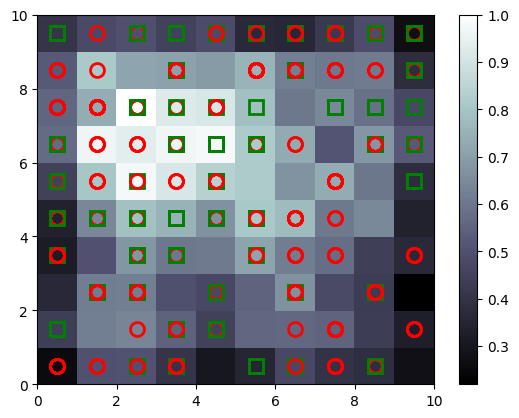

In [11]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']
for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()

# Finding the frauds

In [17]:
mappings = som.win_map(X)

frauds = []

for node in [(2,7), (1,6), (2,6)]:
    if node in mappings:
        frauds.extend(mappings[node])

frauds = np.array(frauds)
frauds = sc.inverse_transform(frauds)
print(frauds)

# Printing the Fradulent clients

print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

[[1.5777994e+07 1.0000000e+00 4.2000000e+01 9.7900000e+00 2.0000000e+00
  1.4000000e+01 8.0000000e+00 7.9600000e+00 1.0000000e+00 1.0000000e+00
  8.0000000e+00 0.0000000e+00 2.0000000e+00 0.0000000e+00 1.0000000e+00]
 [1.5585855e+07 1.0000000e+00 4.0250000e+01 2.1500000e+01 2.0000000e+00
  1.0000000e+01 9.0000000e+00 2.0000000e+01 1.0000000e+00 1.0000000e+00
  1.1000000e+01 0.0000000e+00 2.0000000e+00 0.0000000e+00 1.2010000e+03]
 [1.5597536e+07 1.0000000e+00 2.7670000e+01 2.0000000e+00 2.0000000e+00
  1.4000000e+01 8.0000000e+00 1.0000000e+00 1.0000000e+00 1.0000000e+00
  4.0000000e+00 0.0000000e+00 2.0000000e+00 1.4000000e+02 7.5450000e+03]
 [1.5661412e+07 1.0000000e+00 4.8750000e+01 8.5000000e+00 2.0000000e+00
  8.0000000e+00 8.0000000e+00 1.2500000e+01 1.0000000e+00 1.0000000e+00
  9.0000000e+00 0.0000000e+00 2.0000000e+00 1.8100000e+02 1.6560000e+03]
 [1.5697310e+07 1.0000000e+00 4.1170000e+01 4.0400000e+00 2.0000000e+00
  1.3000000e+01 8.0000000e+00 7.0000000e+00 1.0000000e+00 1.

# Going from Unsupervised to Supervised Deep Learning

In [18]:
# Creating the Matrix of Features
customers = dataset.iloc[:,1:].values

# Creating the dependent variable
is_fraud = np.zeros(len(dataset))
for i in range(len(dataset)):
  if dataset.iloc[i,0] in frauds:
    is_fraud[i] = 1

# ANN
# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
customers = sc.fit_transform(customers)

# Builind ANN

import tensorflow as tf
ann = tf.keras.models.Sequential()

ann.add(tf.keras.layers.Dense(units=2, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# Training ANN
ann.fit(customers, is_fraud, batch_size = 1, epochs = 15)


Epoch 1/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9586 - loss: 0.3961
Epoch 2/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9618 - loss: 0.1990
Epoch 3/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9558 - loss: 0.1478
Epoch 4/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9593 - loss: 0.1184
Epoch 5/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9547 - loss: 0.1146
Epoch 6/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9548 - loss: 0.1037
Epoch 7/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9501 - loss: 0.1052
Epoch 8/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9555 - loss: 0.0916
Epoch 9/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9540 - loss: 0.0888
Epoch 10/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9687 - loss: 0.0653
Epoch 11/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9472 - loss: 0.0903
Epoch 12/15
690/690 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

# Predicting the test set results

In [19]:
y_pred = ann.predict(customers)
y_pred = np.concatenate((dataset.iloc[:, 0:1].values, y_pred), axis = 1)
y_pred = y_pred[y_pred[:, 1].argsort()]

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
